# Chapter 6: The Unexpected Route
We difference a synthetic integrated autoregression, inspect ACF/PACF, fit ARIMA,
and evaluate its future forecast. Diagnostics guide judgment; white-noise
residuals do not prove that all nonlinear predictability has been exhausted.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
rng=begin(6)
d=np.zeros(220)
for t in range(1,len(d)): d[t]=.65*d[t-1]+rng.normal()
y=100+np.cumsum(d); train=y[:190]; test=y[190:]

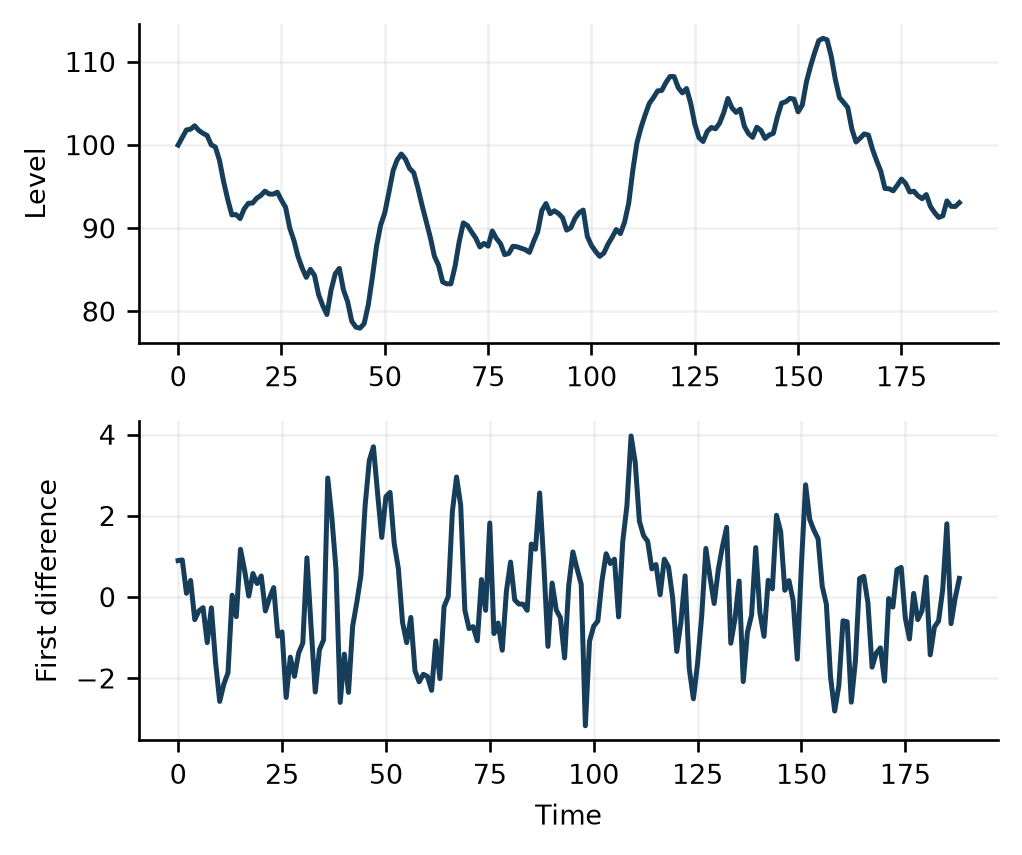

In [2]:
fig,axes=plt.subplots(2,1,figsize=(4.3,3.6)); axes[0].plot(train); axes[0].set_ylabel('Level'); axes[1].plot(np.diff(train)); axes[1].set_ylabel('First difference'); axes[1].set_xlabel('Time')
save(6,1,'Difference the changing level','Synthetic integrated autoregressive observations. First differencing removes the accumulated level without assuming that every trend should be differenced.','## Part Three: What ARIMA Actually Is',fig)

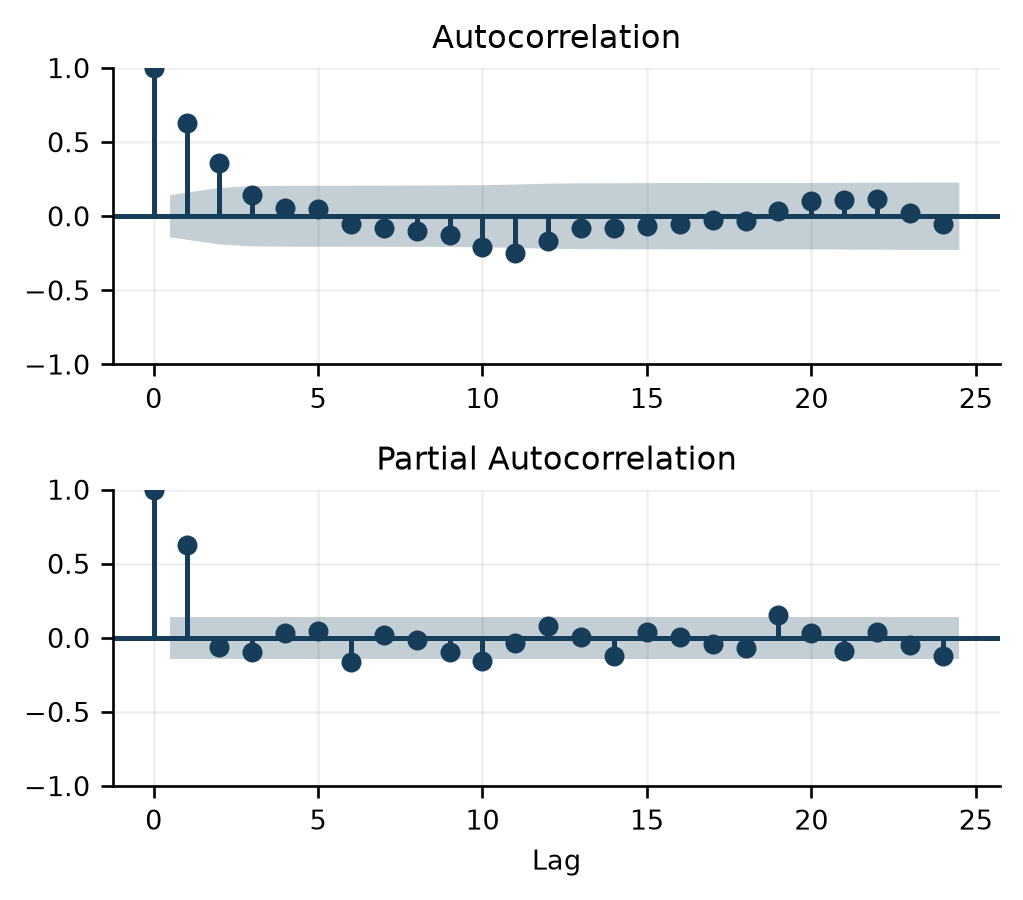

In [3]:
fig,axes=plt.subplots(2,1,figsize=(4.3,3.8)); plot_acf(np.diff(train),lags=24,ax=axes[0]); plot_pacf(np.diff(train),lags=24,ax=axes[1],method='ywm'); axes[1].set_xlabel('Lag')
save(6,2,'A signature in the lag structure','ACF and PACF of training differences only. Approximate confidence bands help screen candidate models; they do not select an order with certainty.','## Part Four: The Full Methodology',fig)

## Forecast before seeing the answers
ARIMA(1,1,0) is prespecified from the demonstration generator. Real selection
must occur within the training window using diagnostics and temporal validation.

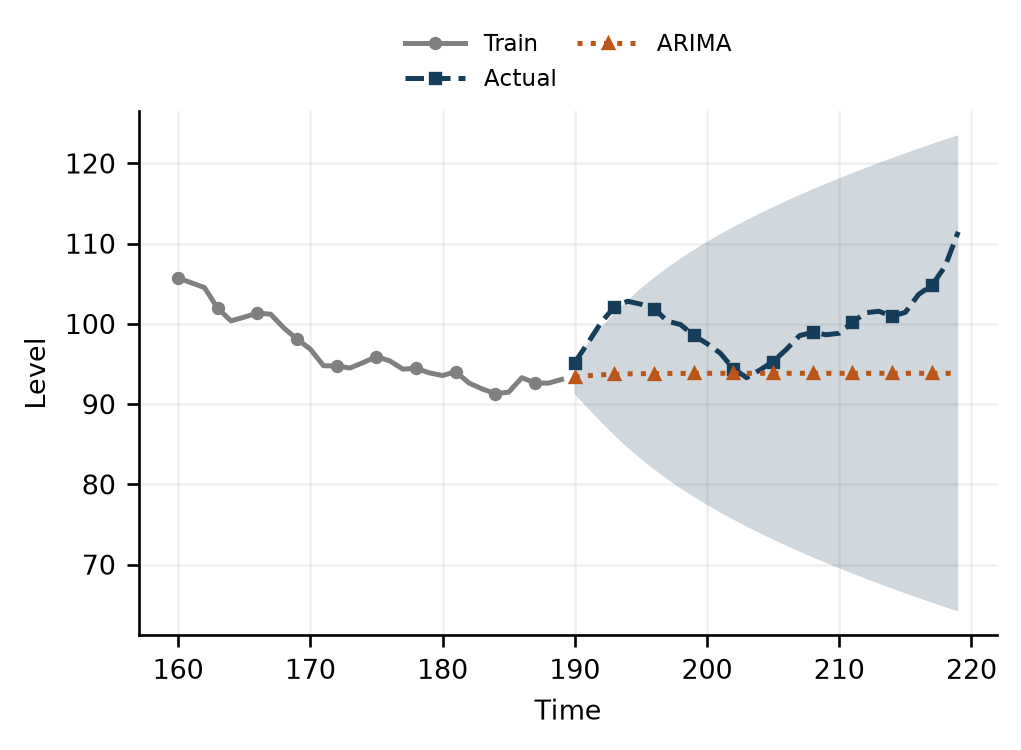

MAE ARIMA: 6.128755562969854 naive: 6.817820906599071
ADF differenced p: 9.341063165721579e-09
      lb_stat  lb_pvalue
12  14.351096   0.278852


In [4]:
model=ARIMA(train,order=(1,1,0)).fit(); prediction=model.get_forecast(len(test)); ci=np.asarray(prediction.conf_int())
plt.figure(); plt.plot(np.arange(160,190),train[-30:],color='.5',label='Train'); plt.plot(np.arange(190,220),test,label='Actual'); plt.plot(np.arange(190,220),prediction.predicted_mean,label='ARIMA'); plt.fill_between(np.arange(190,220),ci[:,0],ci[:,1],alpha=.2); plt.xlabel('Time'); plt.ylabel('Level'); plt.legend(fontsize=7)
save(6,3,'Forecast uncertainty accumulates','Held-out synthetic observations with the ARIMA model\'s nominal 95% prediction interval. Coverage on one path is not a calibration guarantee.','## Part Five: Listening to the Residuals')
print('MAE ARIMA:',mae(test,prediction.predicted_mean),'naive:',mae(test,train[-1]))
print('ADF differenced p:',adfuller(np.diff(train))[1]); print(acorr_ljungbox(model.resid[10:],lags=[12],return_df=True))

## Seasonal ARIMA in a real rolling-origin comparison
A second synthetic series has a lag-12 dependence. At each origin we fit
SARIMA(0,0,0)(1,0,0)[12] to earlier observations and forecast twelve steps.
Orders are prespecified, not selected on the evaluated outcomes. Compare the
same horizons with a nonseasonal ARIMA and seasonal naive; no winner is assumed.

In [5]:
seasonal_y = np.zeros(180)
for day in range(12, len(seasonal_y)):
    seasonal_y[day] = .85*seasonal_y[day-12]+rng.normal(0, 2)
seasonal_y += 40
rolling_errors = {'SARIMA': [], 'ARIMA': [], 'Seasonal naive': []}
for origin in [120, 144, 168]:
    history, actual = seasonal_y[:origin], seasonal_y[origin:origin+12]
    seasonal_fit = ARIMA(history, order=(0,0,0), seasonal_order=(1,0,0,12), trend='c').fit()
    ordinary_fit = ARIMA(history, order=(1,0,0), trend='c').fit()
    forecasts = {'SARIMA': seasonal_fit.forecast(12), 'ARIMA': ordinary_fit.forecast(12),
                 'Seasonal naive': history[-12:]}
    for name, forecast in forecasts.items():
        rolling_errors[name].append(mae(actual, forecast))
assert all(np.isfinite(values).all() for values in rolling_errors.values())
print('Twelve-step MAE by chronological origin:', rolling_errors)
print('Mean rolling MAE:', {name: float(np.mean(values)) for name, values in rolling_errors.items()})

Twelve-step MAE by chronological origin: {'SARIMA': [1.297212440042702, 1.8178391368945253, 2.421295177308164], 'ARIMA': [3.4155398745899297, 4.089055997486537, 2.7658229241896763], 'Seasonal naive': [1.248174569927259, 1.677522137156809, 2.646992403042455]}
Mean rolling MAE: {'SARIMA': 1.8454489180817972, 'ARIMA': 3.423472932088714, 'Seasonal naive': 1.8575630367088412}


## Limits and exercise
Change the AR coefficient or seasonal lag. Add exogenous inputs only when their
future values are known or explicitly scenarized. VAR,
cointegration, GARCH and fractional integration are distinct extensions requiring
separate multivariate or volatility examples; the present notebook is the ARIMA core.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV timestamp,target, unique regular observations; config horizon,season,as_of. The tool searches seasonal ARIMA orders by AICc after diagnostic differencing (KPSS and seasonal strength), alongside the airline model and the baselines; orders are not fixed in advance. The rolling comparison needs 2 seasons + 4 horizons of history (72 monthly points for a 12-month horizon, 48 for six months, 36 for three); with less, the tool returns a provisional persistence baseline and says how many points are missing. Future exogenous values require their own known-at-origin schedule or explicit scenarios.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,target
2026-01-01,100
2026-01-02,102
2026-01-03,101
```

## Explain the mechanism

AR terms use past values; MA terms use past innovations. Integration describes accumulated change requiring differencing. Seasonal versions add dependence at calendar lags. Order selection and forecast validation are separate tasks.

## Work through the arithmetic

For levels [100,103,105], differences are [3,2]. If the last difference is 2 and its AR(1) coefficient is .6 with zero drift, next expected difference is 1.2 and next expected level is 106.2. The second future difference is .72, making the two-step level 106.92.

## Adapt the lesson to reader data

Replace generated y before train/test splitting. For the separate seasonal experiment replace seasonal_y and choose a justified seasonal period. Orders in the teaching source are prespecified from its generator; do not claim they were automatically discovered for user data.

For this chapter, settle these questions before fitting: What is the target frequency and forecast horizon? Are trends deterministic or accumulated shocks? What seasonality exists? Will any future regressors actually be known?

## Interpret the actual lesson outputs

ADF and ACF/PACF use training differences. The forecast chart’s band is nominal model uncertainty. The separate seasonal comparison reports three origins at a twelve-step horizon and does not implement VAR, cointegration or GARCH.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,forecast,model,empirical_q10,empirical_q50,empirical_q90,lower,upper,interval_level,conformal_lower,conformal_upper,band_lower,band_upper`.
- `summary.json`: `profile,gaps_filled,pool,selected,criterion,baseline,forced_baseline,robustness,unavailable,conformal,conformal_test_coverage,selected_by_bucket,band_method,band_note,conformal_m,conformal_level_effective,transform,specification,origins,horizon,season,leaderboard,validation,validation_predictions,test_mae,test_interval_coverage,skipped,executed,evaluation,intervals` plus method, interpretation, assumptions, not_done and status.

The adapter runs the companion engine with the `arima` pool: naive, seasonal naive, drift, ARIMA(0,1,1), ARIMA(1,1,0), the airline model ARIMA(0,1,1)(0,1,1)s, and an AICc-selected seasonal ARIMA whose regular differencing comes from repeated KPSS tests and whose seasonal differencing comes from STL seasonal strength, searched over p,q in 0–2 and P,Q in 0–1 on the first training slice. A log transform is chosen on training data when the series asks for it. Up to five expanding origins select the model; a final untouched holdout scores it once; model intervals are produced and their validation coverage is measured. Short valid histories return a provisional naive baseline and optional seasonal-naive scenario, with no claimed validation.

## Decide what the evidence supports

White residuals do not rule out nonlinear predictability. Differencing can remove useful structure or induce noise when excessive. Intervals depend on parameter/model assumptions and should be assessed by horizon on held-out origins.

With a short series use naive or low-order candidates and mark seasonal fitting unsupported. For calendar gaps, audit the measurement process before imputation. If regressors are unknown, show conditional forecasts or omit the regressor model.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,forecast,model,empirical_q10,empirical_q50,empirical_q90,lower,upper,interval_level,conformal_lower,conformal_upper,band_lower,band_upper`; `summary.json` keys: `profile,gaps_filled,pool,selected,criterion,baseline,forced_baseline,robustness,unavailable,conformal,conformal_test_coverage,selected_by_bucket,band_method,band_note,conformal_m,conformal_level_effective,transform,specification,origins,horizon,season,leaderboard,validation,validation_predictions,test_mae,test_interval_coverage,skipped,executed,evaluation,intervals` plus method, interpretation, assumptions, not_done and status. Return differencing/order rationale, fit warnings, origin-by-horizon benchmark losses, residual diagnostics, dated forecasts and model-interval assumptions.

## Three exercises with worked solutions

### Exercise 1

Levels 10,13,12: first differences?

**Worked solution.** 3 and -1.

### Exercise 2

Residual Ljung–Box does not reject. Is the chosen model proven optimal?

**Worked solution.** No. The test concerns a particular residual dependence diagnostic and has limited power; compare future losses.

### Exercise 3

A future promotion variable becomes known only after the forecast date. May its realized value be used?

**Worked solution.** No. Use the schedule actually known at the origin or label a conditional scenario.

## Business-reader application

Use this request with the skill:

> Apply chapter 6 to sales.csv with a twelve-period horizon, compare supported ARIMA and seasonal-naive candidates at earlier origins, and explain selection and residual limitations.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/monthly-temperature.csv) and [matching config](../configs/ch06-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 6 \
  --input companion/data/observed/monthly-temperature.csv \
  --config companion/configs/ch06-observed.json \
  --output companion/applied-runs/ch06-observed-reader
```

Compare seasonal and nonseasonal candidates without changing their orders after viewing the final test. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch06.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch06.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(6, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch06-workshop-results.csv', index=False)
_ = (workshop_output/'ch06-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Rolling-origin model comparison with final holdout
Status: passed

Interpretation: Airline ARIMA had the lowest mean validation MAE (1.68); the runner-up was ARIMA(auto) (1.69). Final-holdout MAE for the selection: 1.64 against 2.8 for Seasonal naive. Validation MAE of Seasonal naive: 2.43.

Assumptions:
  - Regular series with the declared season and no missing periods
  - The training history's pattern continues over the horizon (no regime change)
  - Specifications are frozen on the first training slice, so later actuals cannot steer selection
Not done:
  - No regressors, promotions or calendar effects (pool regressors, chapter 13 or 16 add them)
  - No hierarchy or coherence constraints (chapter 18)
  - Conformal bands pool the origin and holdout residuals of the selected model; chapter 17 calibrates on a longer window

Evidence:
  profile: <24 entries>
  gaps_filled: 0
  pool: arima
  selected: Airline ARIMA
  criterion: mae
  baseline: Seasonal naive
  forced_baseline: Fa

## The same workflow on observed data

A second run on a bundled public-domain series documented in `data/registry.json` (a revised
historical snapshot, not an archived real-time vintage). The earlier time cuts prevent fitting
on held-out outcomes; they do not undo revisions made before the snapshot was published.
Compare this digest with the controlled case above: a method need not win to be useful, and
the winner on synthetic data has no claim on observed data.

In [7]:
observed_input = pd.read_csv(project_path/'companion/data/observed/monthly-temperature.csv')
observed_config = json.loads((project_path/'companion/configs/ch06-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(6, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(summarize(observed_summary, observed_table))
print()
print(preview(observed_table))
observed_table.to_csv(workshop_output/'ch06-observed-results.csv', index=False)
_ = (workshop_output/'ch06-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels El Niño observations, 1950–2010; historical revised snapshot
Method: Rolling-origin model comparison with final holdout
Status: passed

Interpretation: ARIMA(auto) had the lowest mean validation MAE (0.939); the runner-up was Seasonal naive (1.1). Final-holdout MAE for the selection: 0.648 against 1.21 for Seasonal naive. Validation MAE of Seasonal naive: 1.1.

Assumptions:
  - Regular series with the declared season and no missing periods
  - The training history's pattern continues over the horizon (no regime change)
  - Specifications are frozen on the first training slice, so later actuals cannot steer selection
Not done:
  - No regressors, promotions or calendar effects (pool regressors, chapter 13 or 16 add them)
  - No hierarchy or coherence constraints (chapter 18)
  - Conformal bands pool the origin and holdout residuals of the selected model; chapter 17 calibrates on a longer window

Evidence:
  profile: <24 entries>
  gaps_fill

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **What differencing did the diagnostics call for, and did I check the differenced series looks stationary?**
   A bad answer looks like this: Orders chosen by fit alone, without the stationarity test, produce models that extrapolate a trend that is not there.

2. **Did the model beat seasonal naive at rolling origins, or only fit the history well?**
   A bad answer looks like this: White residuals are a necessary check, not evidence of forecast accuracy.

3. **If I used regressors, do I know their future values, or did I assume them?**
   A bad answer looks like this: An ARIMAX forecast conditional on regressors nobody has yet is a scenario and must be labelled one.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).